In [85]:
import numpy as np
from bigfile import BigFile
import matplotlib.pyplot as plt

In [86]:
# load data
pig = BigFile('/Users/astroyyh/Desktop/Astrid-Baryon/test_pig/PIG_004_subfind')

# n x m ones
r_redge = pig['FOFGroups/RCumProfile'][:]

hubble = pig['Header'].attrs['HubbleParam'][0]

ptypes = [0, 1, 4, 5] # gas, dm, stars, bh

mr = {}
for ptype in ptypes:
    mr[ptype] = pig[f'FOFGroups/MassCumProfileType{ptype}'][:]

In [87]:
pig.keys()

['0/DelayTime',
 '0/Density',
 '0/EgyWtDensity',
 '0/ElectronAbundance',
 '0/GroupID',
 '0/HeIIIIonized',
 '0/ID',
 '0/InternalEnergy',
 '0/Mass',
 '0/Metallicity',
 '0/Metals',
 '0/NeutralHydrogenFraction',
 '0/NewIndex',
 '0/Position',
 '0/SmoothingLength',
 '0/StarFormationRate',
 '0/SubgroupID',
 '0/Velocity',
 '1/GroupID',
 '1/ID',
 '1/Mass',
 '1/NewIndex',
 '1/Position',
 '1/SubgroupID',
 '1/Velocity',
 '4/BirthDensity',
 '4/Generation',
 '4/GroupID',
 '4/ID',
 '4/LastEnrichmentMyr',
 '4/Mass',
 '4/Metallicity',
 '4/Metals',
 '4/NewIndex',
 '4/Position',
 '4/SmoothingLength',
 '4/StarFormationTime',
 '4/SubgroupID',
 '4/TotalMassReturned',
 '4/Velocity',
 '5/BlackholeAccretionRate',
 '5/BlackholeDensity',
 '5/BlackholeJumpToMinPot',
 '5/BlackholeKineticFdbkEnergy',
 '5/BlackholeMass',
 '5/BlackholeMinPotPos',
 '5/BlackholeMseed',
 '5/BlackholeMtrack',
 '5/BlackholeProgenitors',
 '5/BlackholeSwallowID',
 '5/BlackholeSwallowTime',
 '5/Generation',
 '5/GroupID',
 '5/ID',
 '5/Mass',


In [88]:
M200m = pig['FOFGroups/M200m'][:]

In [89]:
pig['FOFGroups/Mass'][:]

array([2.7940250e+02, 2.8977319e+02, 1.3037367e+02, ..., 6.7891203e-02,
       7.0674069e-02, 7.3456936e-02], dtype=float32)

In [90]:
from scipy.interpolate import interp1d

def loglog_interp(r_src, y_src, r_tgt):
    # exclude the first point where r=0 and then attach it back later
    if r_src[0] == 0:
        r_src_nonzero = r_src[1:]
        y_src_nonzero = y_src[1:]
        attach_zero = True
    else:
        r_src_nonzero = r_src
        y_src_nonzero = y_src
        attach_zero = False

    f = interp1d(np.log(r_src_nonzero), np.log(y_src_nonzero), kind='linear', fill_value='extrapolate')

    if r_tgt[0] == 0 and attach_zero:
        y_tgt_nonzero = np.exp(f(np.log(r_tgt[1:])))
        y_tgt = np.concatenate(([y_src[0]], y_tgt_nonzero))
    else:
        y_tgt = np.exp(f(np.log(r_tgt)))

    return y_tgt

def get_rho_profile_type(pig, ptype):
    r_redge = pig['FOFGroups/RCumProfile'][:]

    hubble = pig['Header'].attrs['HubbleParam'][0]

    mr = pig[f'FOFGroups/MassCumProfileType{ptype}'][:]

    r_bin = np.concatenate((np.zeros((r_redge.shape[0], 1)), r_redge), axis=1)

    vol_shell = (4.0/3.0) * np.pi * (r_bin[:, 1:]**3 - r_bin[:, :-1]**3)

    mass_shell = np.zeros_like(mr)
    mass_shell[:, 0] = mr[:, 0]
    mass_shell[:, 1:] = mr[:, 1:] - mr[:, :-1]

    density_prof = mass_shell / vol_shell 

    r_bin_mid = np.sqrt(r_bin[:, 1:] * r_bin[:, :-1]) 

    density_prof *= 1e10 * hubble**2
    r_bin_mid /= hubble

    return r_bin_mid, density_prof

def get_rho_profile(pig):  # total matter density profile

    # extract available particle types
    # find FOFGroups/MassCumProfileType* in pig.keys()
    ptypes = []
    for key in pig.keys():
        if key.startswith('FOFGroups/MassCumProfileType'):
            ptype = int(key.split('Type')[-1])
            ptypes.append(ptype)

    # get density profile for each particle type
    density_profiles = []
    for ptype in ptypes:
        r_bin_mid, density_prof = get_rho_profile_type(pig, ptype)
        density_profiles.append(density_prof)

    # sum to get total density profile
    density_prof = np.sum(density_profiles, axis=0)

    return r_bin_mid, density_prof

# stacked density profile, halo mass from m_lower to m_upper
# def get_stacked_rho_profile(pig, m_lower, m_upper, mass_def='M500c'):
    # mass_def can be 'M200m', 'M200c' or 'M500c'
    # m_lower and m_upper in units of Msun/h
    halo_masses = pig[f'FOFGroups/{mass_def}'][:]
    # index mask for halos within the mass range
    mask = (halo_masses >= m_lower/1e10) & (halo_masses < m_upper/1e10)
    # warn if no halos found
    if np.sum(mask) == 0:
        print(f'Warning: No halos found in mass range {m_lower:.2e}--{m_upper:.2e} Msun/h')
        return None, None
    # get density profiles for selected halos
    r_bin_mid, density_prof = get_rho_profile(pig)
    selected_density_prof = density_prof[mask, :]
    r_bin_mid = r_bin_mid[mask, :]
    # interpolate to common radial bins: use the smallest range of r_bin_mid across selected halos
    i_common = np.argmin(r_bin_mid[:, -1])  # find where r_bin_mid[:, -1] is minimum
    r_common = r_bin_mid[i_common, :]
    # interpolate in log-log space
    density_prof_interp = np.zeros_like(selected_density_prof)
    for i in range(selected_density_prof.shape[0]):
        density_prof_interp[i, :] = loglog_interp(r_bin_mid[i, :], selected_density_prof[i, :], r_common)
    # average over halos
    stacked_density_prof = np.mean(density_prof_interp, axis=0)

    return r_common, stacked_density_prof

# stacked density profile, halo mass from m_lower to m_upper
def get_stacked_rho_profile(pig, m_lower, m_upper, mass_def='M500c'):
    """
    Return stacked density profile and 16--84 percentile range.

    Parameters
    ----------
    pig : BigFile
    m_lower, m_upper : float
        Halo mass range in Msun/h
    mass_def : str
        'M200m', 'M200c', or 'M500c'

    Returns
    -------
    r_common : array
        Common radial bins
    rho_med : array
        Median stacked density profile
    rho_p16 : array
        16th percentile density profile
    rho_p84 : array
        84th percentile density profile
    """

    halo_masses = pig[f'FOFGroups/{mass_def}'][:]

    # mask halos in mass range (stored in 1e10 Msun/h)
    mask = (halo_masses >= m_lower / 1e10) & (halo_masses < m_upper / 1e10)

    if np.sum(mask) == 0:
        print(f'Warning: No halos found in mass range {m_lower:.2e}--{m_upper:.2e} Msun/h')
        return None, None, None, None

    # get individual halo profiles
    r_bin_mid, density_prof = get_rho_profile(pig)

    selected_density_prof = density_prof[mask, :]
    r_bin_mid = r_bin_mid[mask, :]

    # define common radial range: 0, largest of min r_min, smallest of max r_max
    r_nonzero_lower = np.max(r_bin_mid[:, 1])  # exclude r=0
    r_nonzero_upper = np.min(r_bin_mid[:, -1])
    # common r grid: 0, logspace between r_nonzero_lower and r_nonzero_upper
    n_bin = r_bin_mid.shape[1]
    r_common_nonzero = np.logspace(np.log10(r_nonzero_lower), np.log10(r_nonzero_upper), n_bin - 1)
    r_common = np.concatenate(([0.0], r_common_nonzero))

    # interpolate all profiles to common r grid (log-log)
    n_halo = selected_density_prof.shape[0]
    n_bin = len(r_common)
    density_prof_interp = np.zeros((n_halo, n_bin))

    for i in range(n_halo):
        density_prof_interp[i, :] = loglog_interp(
            r_bin_mid[i, :],
            selected_density_prof[i, :],
            r_common
        )
        # for debugging
        # print something if density_prof_interp[i, 4] is nan
        if np.isnan(density_prof_interp[i, 4]):
            print(f'Warning: NaN in interpolated profile for halo {i}')
            print(f'r_bin_mid: {r_bin_mid[i, :]}')
            print(f'selected_density_prof: {selected_density_prof[i, :]}')

    # stack in log space
    log_rho = np.log10(density_prof_interp)

    log_rho_med = np.median(log_rho, axis=0)
    # find the index of the first non-nan value backwards: log_rho_med
    i_nonan = np.where(~np.isnan(log_rho_med))[0][-1]
    # cut off at i_nonan
    log_rho = log_rho[:, :i_nonan+1]
    r_common = r_common[:i_nonan+1]
    
    # log_rho_p16 = np.percentile(log_rho, 16, axis=0)
    # log_rho_p84 = np.percentile(log_rho, 84, axis=0)

    log_rho_med = np.nanmedian(log_rho, axis=0)
    log_rho_p16 = np.nanpercentile(log_rho, 16, axis=0)
    log_rho_p84 = np.nanpercentile(log_rho, 84, axis=0)

    # back to linear space
    rho_med = 10**log_rho_med
    rho_p16 = 10**log_rho_p16
    rho_p84 = 10**log_rho_p84

    return r_common, rho_med, rho_p16, rho_p84

In [91]:
pig['FOFGroups/M200m'][:].min()

0.0

/var/folders/f2/_m97yrqd1x383mz_47xpv__w0000gn/T/ipykernel_60684/1693321014.py:39: RuntimeWarning: invalid value encountered in divide
  density_prof = mass_shell / vol_shell


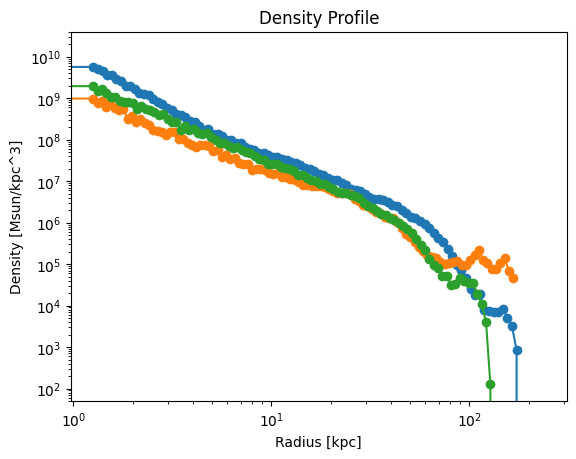

In [92]:
r_all, rho_all = get_rho_profile(pig)

# make a plot of density profile



fig, ax = plt.subplots()

ax.plot(r_all[0], rho_all[0], marker='o')
ax.plot(r_all[1], rho_all[1], marker='o')
ax.plot(r_all[2], rho_all[2], marker='o')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Radius [kpc]')
ax.set_ylabel('Density [Msun/kpc^3]')
ax.set_title('Density Profile')
plt.show()

In [93]:
r_all.shape

(25610, 100)

In [94]:
r_all[r_all[:,1]>0]

array([[  0.        ,   1.26353036,   1.33293783, ..., 214.3438382 ,
        226.11805616, 238.53903243],
       [  0.        ,   1.26121372,   1.32561956, ..., 150.41442844,
        158.09557554, 166.16897319],
       [  0.        ,   1.26179588,   1.32745605, ..., 164.42603983,
        172.982299  , 181.9837953 ],
       ...,
       [  0.        ,   1.25058264,   1.29237944, ...,  29.36069884,
         30.34198921,  31.35607514],
       [  0.        ,   1.2506013 ,   1.29243723, ...,  29.4452354 ,
         30.43025581,  31.4482294 ],
       [  0.        ,   1.25044086,   1.29193992, ...,  28.72524102,
         29.67856163,  30.66352078]])

/var/folders/f2/_m97yrqd1x383mz_47xpv__w0000gn/T/ipykernel_60684/1693321014.py:39: RuntimeWarning: invalid value encountered in divide
  density_prof = mass_shell / vol_shell
/var/folders/f2/_m97yrqd1x383mz_47xpv__w0000gn/T/ipykernel_60684/1693321014.py:14: RuntimeWarning: divide by zero encountered in log
  f = interp1d(np.log(r_src_nonzero), np.log(y_src_nonzero), kind='linear', fill_value='extrapolate')
/var/folders/f2/_m97yrqd1x383mz_47xpv__w0000gn/T/ipykernel_60684/1693321014.py:163: RuntimeWarning: divide by zero encountered in log10
  log_rho = np.log10(density_prof_interp)


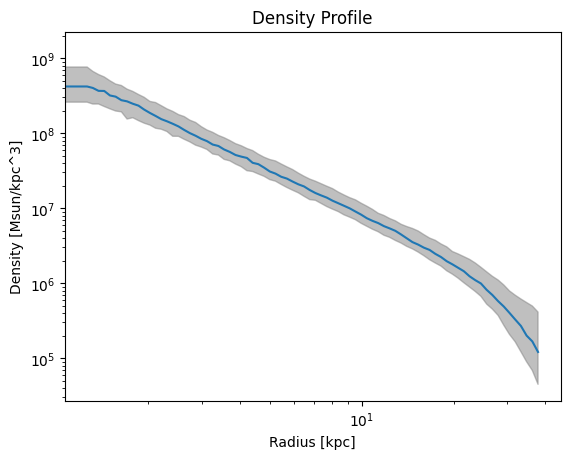

In [95]:
m_lower = 1e11  # Msun/h
m_upper = 5e11  # Msun/h

r, rho, rho_p16, rho_p84 = get_stacked_rho_profile(pig, m_lower, m_upper)

fig, ax = plt.subplots()

ax.plot(r, rho,)
# 16th and 84th percentiles
ax.fill_between(r, rho_p16, rho_p84, color='gray', alpha=0.5, label='16-84 percentile')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Radius [kpc]')
ax.set_ylabel('Density [Msun/kpc^3]')
ax.set_title('Density Profile')
plt.show()

In [96]:
rho

array([7.39534927e+08, 4.20711809e+08, 4.02265003e+08, 3.67938034e+08,
       3.66614194e+08, 3.19374679e+08, 3.07887734e+08, 2.76176690e+08,
       2.66461629e+08, 2.47768419e+08, 2.33595933e+08, 2.06881724e+08,
       1.86711827e+08, 1.70197074e+08, 1.54344583e+08, 1.44385903e+08,
       1.33943589e+08, 1.23498243e+08, 1.10936217e+08, 1.00502081e+08,
       9.27106597e+07, 8.43961108e+07, 7.85876045e+07, 7.07452860e+07,
       6.77135798e+07, 6.08174934e+07, 5.63942527e+07, 5.13340380e+07,
       4.88461718e+07, 4.68828845e+07, 4.03866518e+07, 3.87371646e+07,
       3.48418739e+07, 3.09486496e+07, 2.89897026e+07, 2.63210797e+07,
       2.48830548e+07, 2.27123988e+07, 2.08770877e+07, 1.95527940e+07,
       1.75171864e+07, 1.59691742e+07, 1.48375586e+07, 1.38572445e+07,
       1.26149284e+07, 1.16778438e+07, 1.08011798e+07, 9.98001254e+06,
       9.05597734e+06, 8.23216621e+06, 7.37259969e+06, 6.79518026e+06,
       6.34441188e+06, 5.77822540e+06, 5.39358678e+06, 5.00125701e+06,
      

In [97]:
r

array([ 0.        ,  1.26061851,  1.31608724,  1.37399667,  1.43445418,
        1.4975719 ,  1.56346687,  1.6322613 ,  1.70408277,  1.77906447,
        1.85734545,  1.93907089,  2.02439235,  2.11346806,  2.20646321,
        2.30355025,  2.40490924,  2.51072815,  2.62120322,  2.73653933,
        2.85695036,  2.98265963,  3.11390025,  3.25091562,  3.39395983,
        3.54329816,  3.69920756,  3.86197716,  4.03190881,  4.20931767,
        4.39453273,  4.58789747,  4.7897705 ,  5.00052619,  5.22055537,
        5.45026611,  5.6900844 ,  5.94045498,  6.20184217,  6.47473072,
        6.75962668,  7.05705842,  7.36757751,  7.69175981,  8.03020653,
        8.38354531,  8.75243143,  9.13754897,  9.53961216,  9.95936661,
       10.39759077, 10.85509731, 11.3327347 , 11.8313887 , 12.35198409,
       12.8954863 , 13.46290327, 14.05528726, 14.67373687, 15.31939901,
       15.99347106, 16.69720309, 17.43190018, 18.19892483, 18.9996995 ,
       19.83570921, 20.70850436, 21.61970355, 22.57099661, 23.56